# Análisis Exploratorio y Limpieza de Datos Inmobiliarios

**Objetivo:** Realizar el procesamiento, limpieza y análisis descriptivo de un conjunto de datos de bienes raíces en Ecuador para garantizar su calidad y coherencia antes del modelado.

**Tareas principales:**
* Conversión de tipos de datos y manejo de valores nulos.
* Identificación y tratamiento de valores atípicos (outliers).
* Análisis estadístico descriptivo (precios por ubicación).
* Visualización de relaciones entre variables físicas y el precio.

**Resultado esperado:** Un dataset refinado y listo para la fase de Machine Learning.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import numpy as np

df = pd.read_csv('../data/real_state_ecuador_dataset.csv')
df = df.drop(columns=['Titulo'])
df.head()
df.info()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Precio            500 non-null    int64  
 1   Provincia         500 non-null    str    
 2   Lugar             500 non-null    str    
 3   Num. dormitorios  360 non-null    str    
 4   Num. banos        403 non-null    float64
 5   Area              482 non-null    float64
 6   Num. garages      348 non-null    float64
dtypes: float64(3), int64(1), str(3)
memory usage: 27.5 KB


Precio                0
Provincia             0
Lugar                 0
Num. dormitorios    140
Num. banos           97
Area                 18
Num. garages        152
dtype: int64

In [2]:

columnas_a_convertir = [
    'Area', 'Num. dormitorios', 'Num. banos', 'Num. garages']

for col in columnas_a_convertir:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df['Area'] = df['Area'].fillna(df['Area'].median())
df['Num. dormitorios'] = df['Num. dormitorios'].fillna(
    df['Num. dormitorios'].median())
df['Num. banos'] = df['Num. banos'].fillna(df['Num. banos'].median())

df['Num. garages'] = df['Num. garages'].fillna(0)

df = df[df['Area'] > 5]

print("Conteo de nulos tras la limpieza:")
print(df.isnull().sum())
print(f"\nDimensiones finales del dataset: {df.shape}")

Conteo de nulos tras la limpieza:
Precio              0
Provincia           0
Lugar               0
Num. dormitorios    0
Num. banos          0
Area                0
Num. garages        0
dtype: int64

Dimensiones finales del dataset: (499, 7)


### Tratamiento de Valores Atípicos (Outliers)
Se aplicó el método del Rango Intercuartílico (IQR) sobre las variables numéricas clave (`Precio` y `Area`). 

**Justificación técnica:** La eliminación de valores extremos (errores de captura o anomalías del mercado) es fundamental para evitar el sesgo en las métricas de tendencia central (como la media) y garantizar la robustez de las visualizaciones y posteriores análisis estadísticos.

In [3]:
print(f"Propiedades antes de limpiar outliers: {df.shape[0]}")


def quitar_outliers(df, columna):
    Q1 = df[columna].quantile(0.25)
    Q3 = df[columna].quantile(0.75)
    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    return df[(df[columna] >= limite_inferior) & (df[columna] <= limite_superior)]


df = quitar_outliers(df, 'Precio')

df = quitar_outliers(df, 'Area')

print(f"Propiedades después de limpiar outliers: {df.shape[0]}")

Propiedades antes de limpiar outliers: 499
Propiedades después de limpiar outliers: 415


In [4]:
df['Lugar'] = df['Lugar'].astype(str).str.lower().str.strip()
df['Lugar'] = df['Lugar'].str.normalize('NFKD').str.encode(
    'ascii', errors='ignore').str.decode('utf-8')


def limpiar_lugar_estricto(texto):
    partes = texto.split(',')

    if len(partes) == 4:
        tercera_parte = partes[2].strip()

        if 'avenida' in tercera_parte or 'av.' in tercera_parte or 'calle' in tercera_parte or 'via' in tercera_parte:
            return np.nan

        solo_texto = re.sub(r'\d+', '', tercera_parte).strip()
        return solo_texto
    else:
        return np.nan


df['Lugar'] = df['Lugar'].apply(limpiar_lugar_estricto)

descartados = df['Lugar'].isnull().sum()
print(
    f"Propiedades descartadas por mal formato o ser direcciones: {descartados}")

df = df.dropna(subset=['Lugar'])

print(f"Propiedades útiles restantes: {df.shape[0]}\n")
print("--- CIUDADES EXTRAÍDAS ---")
print(df['Lugar'].unique()[:15])

Propiedades descartadas por mal formato o ser direcciones: 84
Propiedades útiles restantes: 331

--- CIUDADES EXTRAÍDAS ---
<StringArray>
['quito', 'sangolqui', 'guayaquil', 'babahoyo', 'tonsupa']
Length: 5, dtype: str


In [5]:
total_propiedades = df.shape[0]
print(f"Total de propiedades analizadas: {total_propiedades}\n")

print("--- Cantidad de Propiedades por Provincia ---")
prop_provincia = df['Provincia'].value_counts()
print(prop_provincia)

Total de propiedades analizadas: 331

--- Cantidad de Propiedades por Provincia ---
Provincia
Pichincha     306
Guayas         21
Los Rios        3
Esmeraldas      1
Name: count, dtype: int64


In [6]:
print("--- Top 10 Lugares con más propiedades ---")
prop_lugar = df['Lugar'].value_counts().head(10)
print(prop_lugar)

--- Top 10 Lugares con más propiedades ---
Lugar
quito        295
guayaquil     21
sangolqui     11
babahoyo       3
tonsupa        1
Name: count, dtype: int64


In [7]:
precio_promedio_general = df['Precio'].mean()
precio_mediana_general = df['Precio'].median()

print("--- ANÁLISIS GENERAL DE PRECIOS ---")
print(f"Precio Promedio General: ${precio_promedio_general:,.2f}")
print(f"Precio Mediana General:  ${precio_mediana_general:,.2f}\n")

--- ANÁLISIS GENERAL DE PRECIOS ---
Precio Promedio General: $500.11
Precio Mediana General:  $470.00



In [8]:
print("--- ANÁLISIS DE PRECIOS POR LUGAR ---")
precios_lugar = df.groupby('Lugar')['Precio'].agg(
    ['mean', 'median']).reset_index()

precios_lugar.rename(
    columns={'mean': 'Precio Promedio', 'median': 'Precio Mediana'}, inplace=True)

precios_lugar = precios_lugar.sort_values(
    by='Precio Promedio', ascending=False)

display(precios_lugar.head(10).round(2))

--- ANÁLISIS DE PRECIOS POR LUGAR ---


,Lugar,Precio Promedio,Precio Mediana
1,guayaquil,530.90,500.0
4,tonsupa,508.00,508.0
2,quito,500.68,470.0
3,sangolqui,498.18,675.0
0,babahoyo,233.33,240.0


Coeficiente de correlación entre Área y Precio: 0.4696


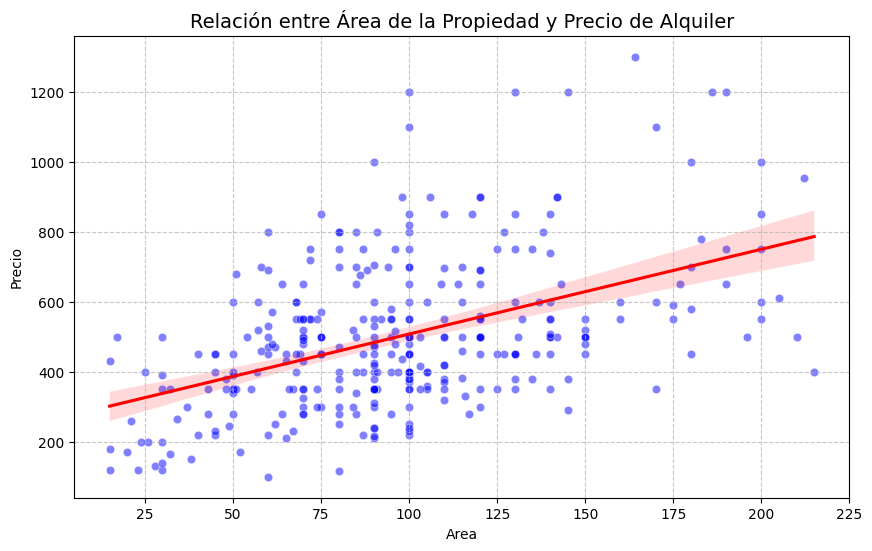

In [9]:
correlacion = df['Area'].corr(df['Precio'])
print(f"Coeficiente de correlación entre Área y Precio: {correlacion:.4f}")

plt.figure(figsize=(10, 6))

sns.scatterplot(data=df, x='Area', y='Precio', alpha=0.5, color='b')

plt.title('Relación entre Área de la Propiedad y Precio de Alquiler', fontsize=14)
plt.xlabel('Área')
plt.ylabel('Precio de Alquiler ($)')

sns.regplot(data=df, x='Area', y='Precio', scatter=False, color='red')

plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [10]:
df_habitaciones = df[df['Num. dormitorios'].between(1, 5)]

premium_hab = df_habitaciones.groupby('Num. dormitorios')[
    'Precio'].mean().reset_index()

premium_hab['Premium por Habitación Extra'] = premium_hab['Precio'].diff()

premium_hab.rename(columns={'Precio': 'Precio Promedio'}, inplace=True)
premium_hab['Precio Promedio'] = premium_hab['Precio Promedio'].round(2)
premium_hab['Premium por Habitación Extra'] = premium_hab['Premium por Habitación Extra'].round(
    2)

print("--- INCREMENTO DE PRECIO POR HABITACIÓN ADICIONAL ---")
display(premium_hab)

--- INCREMENTO DE PRECIO POR HABITACIÓN ADICIONAL ---


,Num. dormitorios,Precio Promedio,Premium por Habitación Extra
0,1.0,468.63,NaN
1,2.0,471.10,2.47
2,3.0,513.88,42.78
3,4.0,601.11,87.23
4,5.0,650.00,48.89


### Creación de Columna: Tipo de Precio por Lugar
Se segmentan los inmuebles en categorías de mercado ("Económico", "Medio", "Lujo").
Para evitar sesgos geográficos, los umbrales (Cuartil 1 y Cuartil 3) no se calculan de manera global, sino que son dinámicos y dependientes de cada `Lugar` (sector/ciudad), utilizando agrupaciones mediante la función `transform`.

In [11]:
Q1_lugar = df.groupby('Lugar')['Precio'].transform(lambda x: x.quantile(0.25))
Q3_lugar = df.groupby('Lugar')['Precio'].transform(lambda x: x.quantile(0.75))

condiciones = [
    (df['Precio'] < Q1_lugar),
    (df['Precio'] > Q3_lugar)
]

etiquetas = ['Económico', 'Lujo']

df['Tipo de Precio'] = np.select(condiciones, etiquetas, default='Medio')

print("--- DISTRIBUCIÓN DE TIPO DE PRECIO ---")
print(df['Tipo de Precio'].value_counts())

display(df[['Lugar', 'Precio', 'Tipo de Precio']].head(10))

--- DISTRIBUCIÓN DE TIPO DE PRECIO ---
Tipo de Precio
Medio        192
Lujo          82
Económico     57
Name: count, dtype: int64


,Lugar,Precio,Tipo de Precio
0,quito,500,Medio
2,quito,650,Lujo
5,quito,460,Medio
6,quito,435,Medio
7,quito,750,Lujo
8,quito,570,Medio
10,quito,500,Medio
11,quito,360,Medio
12,quito,560,Medio
13,quito,450,Medio


In [12]:
ruta_guardado = '../data/real_state_ecuador_limpio.csv'

df.to_csv(ruta_guardado, index=False, encoding='utf-8')